# Pipeline de entrenamiento del modelo top-7 de VetSur

Notebook canónico y determinista: limpia el texto, imputa el costo de medicamento, construye 44 features, selecciona las 7 más importantes sobre el split de entrenamiento, calibra el modelo con Random Forest y exporta los artefactos de producción (`modelo_vetsur.pkl`, `columnas_vetsur.json`, `imputaciones_vetsur.json`). Ejecutar desde el directorio `notebooks/` para que las rutas relativas a `../api/` funcionen.

In [1]:
import json
import unicodedata
from pathlib import Path

import ftfy
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import brier_score_loss, classification_report, log_loss, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, train_test_split

ruta_csv = Path.cwd().parent / 'api' / 'caso1_vetsur.csv'
if not ruta_csv.exists():
    raise FileNotFoundError(f"Archivo de datos no encontrado: {ruta_csv.resolve()}")

df = pd.read_csv(ruta_csv, encoding='latin1')
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas desde {ruta_csv.resolve()}")

Dataset cargado: 1400 filas, 14 columnas desde C:\Users\daemon\Documents\proyectosv2\vetsur\api\caso1_vetsur.csv


In [2]:
def normalizar_texto(texto):
    if pd.isna(texto):
        return ''
    texto = str(texto).replace('exa³tico', 'exotico').replace('Exa³tico', 'Exotico')
    texto = ftfy.fix_text(texto)
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')
    return texto.lower().strip().replace(' ', '_').replace('.', '').replace('-', '_')

for col in ['especie', 'sucursal', 'tipo_atencion', 'diagnostico_texto']:
    df[col] = df[col].apply(normalizar_texto)

mediana_monto = float(df['monto_cobrado'].median())
mediana_costo_global = float(df['costo_medicamento'].median())
mediana_costo_por_atencion = df.groupby('tipo_atencion')['costo_medicamento'].median().to_dict()

df['costo_medicamento'] = df.groupby('tipo_atencion')['costo_medicamento'].transform(lambda x: x.fillna(x.median()))
df['costo_medicamento'] = df['costo_medicamento'].fillna(mediana_costo_global)

print('Medianas de imputación por tipo de atención:')
for tipo, mediana in mediana_costo_por_atencion.items():
    print(f'  {tipo}: {mediana}')
print(f'Mediana global de costo de medicamento: {mediana_costo_global}')
print(f'Mediana de monto cobrado: {mediana_monto}')

Medianas de imputación por tipo de atención:
  cirugia: 54350.0
  consulta_especialidad: 13950.0
  consulta_general: 6700.0
  hospitalizacion: 32100.0
  venta_producto: 5200.0
Mediana global de costo de medicamento: 9500.0
Mediana de monto cobrado: 42100.0


In [3]:
columnas_numericas = [
    'dias_desde_ultima_visita',
    'visitas_historicas',
    'monto_cobrado',
    'costo_medicamento',
    'edad_mascota_anios',
    'tiene_vacunas_al_dia',
    'raza_registrada',
]

columnas_categoricas = ['especie', 'sucursal', 'tipo_atencion', 'diagnostico_texto']
df_onehot = pd.get_dummies(df[columnas_categoricas], prefix=columnas_categoricas, drop_first=False, dtype=int)

X = pd.concat([df[columnas_numericas], df_onehot], axis=1)
y = (df['retorno_90d'] == 0).astype(int)

print(f'Features construidas: {X.shape[1]} columnas')
print('Distribución del target (1 = fuga, 0 = retorno):')
print(f'  Fuga: {(y == 1).sum()} casos ({(y == 1).mean() * 100:.1f}%)')
print(f'  Retorno: {(y == 0).sum()} casos ({(y == 0).mean() * 100:.1f}%)')

Features construidas: 44 columnas
Distribución del target (1 = fuga, 0 = retorno):
  Fuga: 560 casos (40.0%)
  Retorno: 840 casos (60.0%)


## Gráfico 1: Distribución del target

C:\Users\daemon\AppData\Local\Temp\ipykernel_16680\3544069204.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='retorno_90d', data=df, palette=['#2c3e50', '#16a085'])


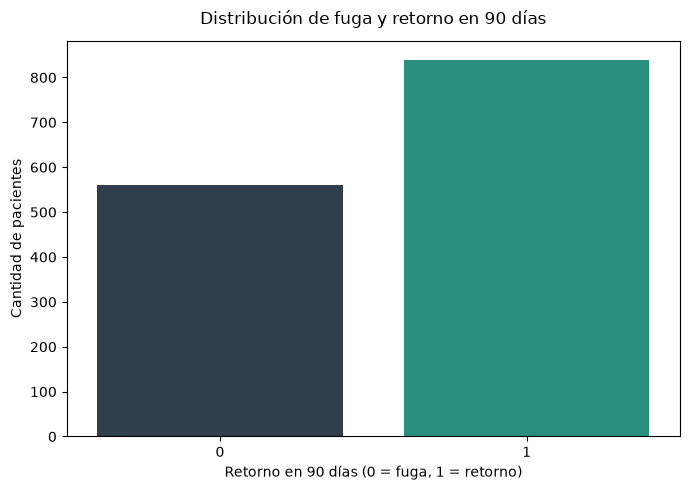

In [4]:
plt.figure(figsize=(7, 5))
sns.countplot(x='retorno_90d', data=df, palette=['#2c3e50', '#16a085'])
plt.title('Distribución de fuga y retorno en 90 días', fontsize=12, pad=12)
plt.xlabel('Retorno en 90 días (0 = fuga, 1 = retorno)')
plt.ylabel('Cantidad de pacientes')
plt.tight_layout()
plt.show()

## Gráfico 2: Matriz de correlación

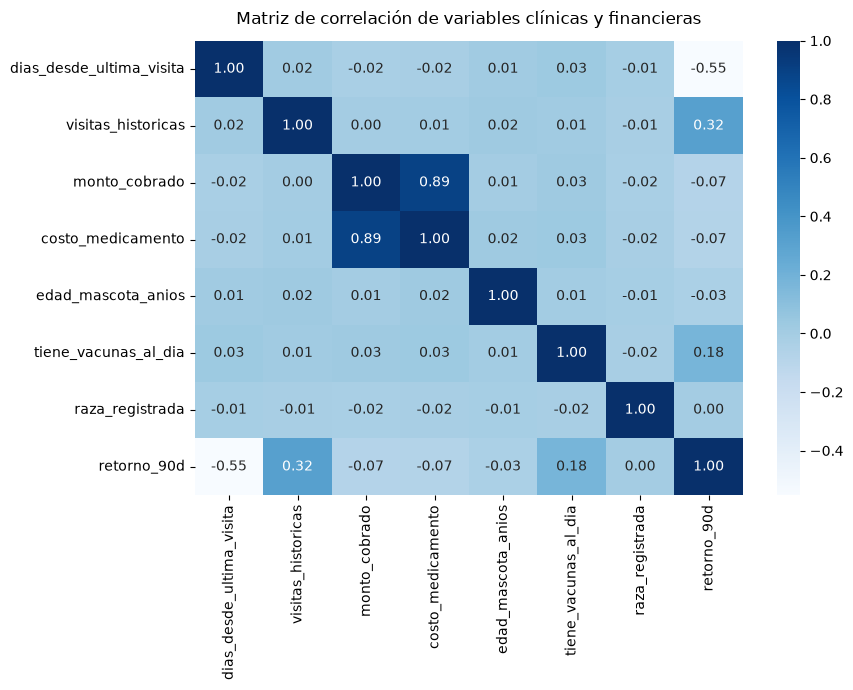

In [5]:
columnas_correlacion = columnas_numericas + ['retorno_90d']
plt.figure(figsize=(9, 7))
sns.heatmap(df[columnas_correlacion].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Matriz de correlación de variables clínicas y financieras', fontsize=12, pad=12)
plt.tight_layout()
plt.show()

## Gráfico 3: Tasa de retorno según vacunación

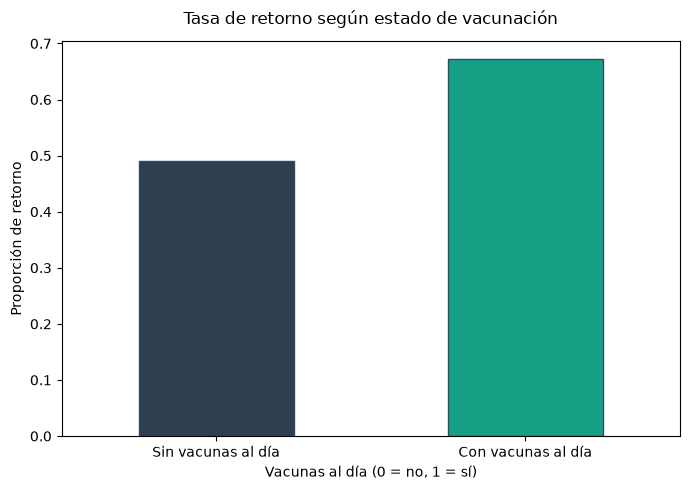

In [6]:
plt.figure(figsize=(7, 5))
tasa_retorno_vacunas = df.groupby('tiene_vacunas_al_dia')['retorno_90d'].mean()
tasa_retorno_vacunas.plot(kind='bar', color=['#2c3e50', '#16a085'], edgecolor='#34495e')
plt.title('Tasa de retorno según estado de vacunación', fontsize=12, pad=12)
plt.xlabel('Vacunas al día (0 = no, 1 = sí)')
plt.ylabel('Proporción de retorno')
plt.xticks(ticks=[0, 1], labels=['Sin vacunas al día', 'Con vacunas al día'], rotation=0)
plt.tight_layout()
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

rf_seleccion = RandomForestClassifier(
    n_estimators=150,
    max_depth=6,
    min_samples_split=8,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
)
rf_seleccion.fit(X_train, y_train)

importancias = pd.Series(rf_seleccion.feature_importances_, index=X.columns).sort_values(ascending=False)
top7 = importancias.head(7).index.tolist()
print('Las 7 features seleccionadas por importancia:')
for col in top7:
    print(f'  {col}: {importancias[col]:.4f}')

Las 7 features seleccionadas por importancia:
  dias_desde_ultima_visita: 0.4817
  visitas_historicas: 0.1519
  tipo_atencion_consulta_general: 0.0484
  tiene_vacunas_al_dia: 0.0479
  monto_cobrado: 0.0476
  tipo_atencion_venta_producto: 0.0472
  costo_medicamento: 0.0437


## Gráfico 4: Importancia de las variables seleccionadas

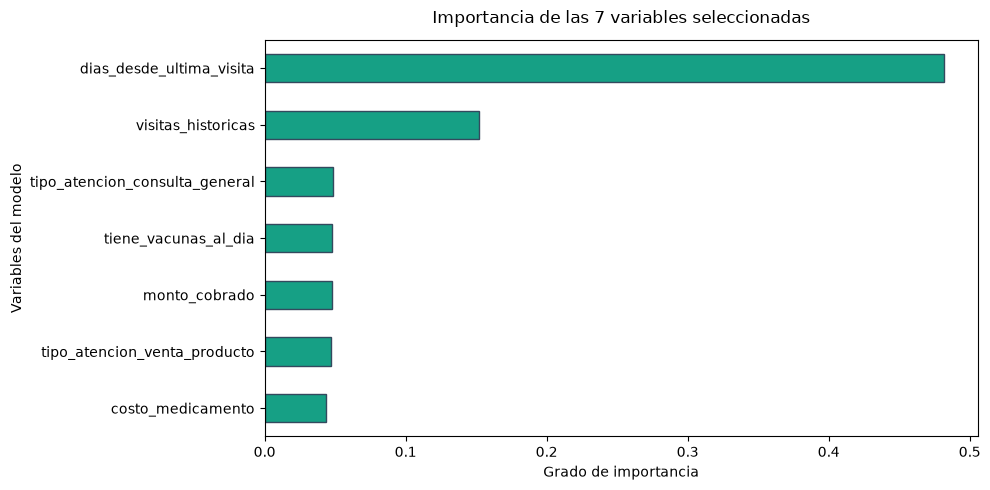

In [8]:
plt.figure(figsize=(10, 5))
importancias.loc[top7].sort_values().plot(kind='barh', color='#16a085', edgecolor='#34495e')
plt.title('Importancia de las 7 variables seleccionadas', fontsize=12, pad=12)
plt.xlabel('Grado de importancia')
plt.ylabel('Variables del modelo')
plt.tight_layout()
plt.show()

AUC-ROC: 0.9346
Brier score: 0.0999
Log-loss: 0.3230
Reporte de clasificación:
                precision    recall  f1-score   support

Fidelizado (0)       0.86      0.93      0.89       168
      Fuga (1)       0.88      0.78      0.82       112

      accuracy                           0.87       280
     macro avg       0.87      0.85      0.86       280
  weighted avg       0.87      0.87      0.87       280



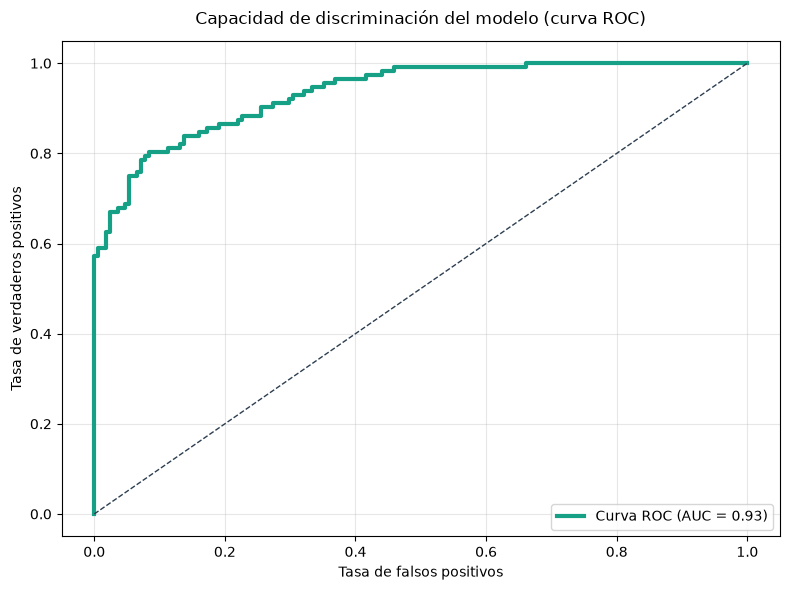

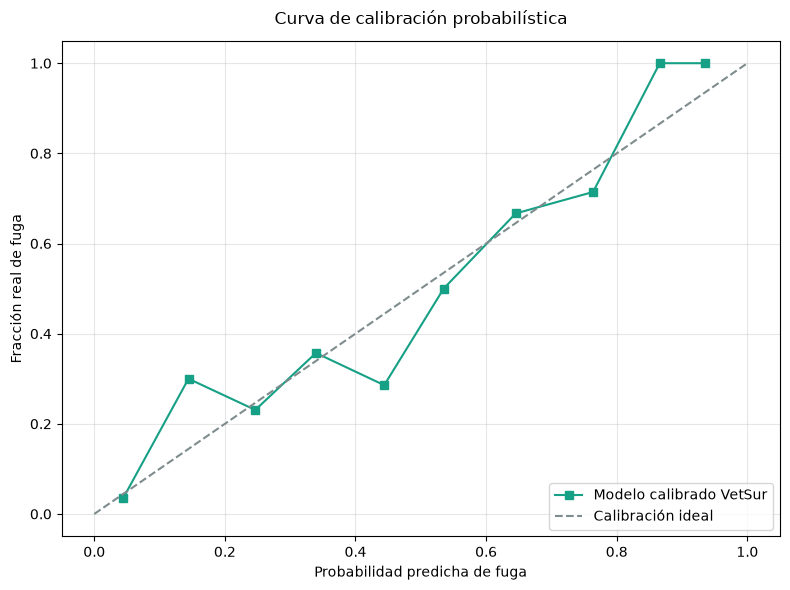

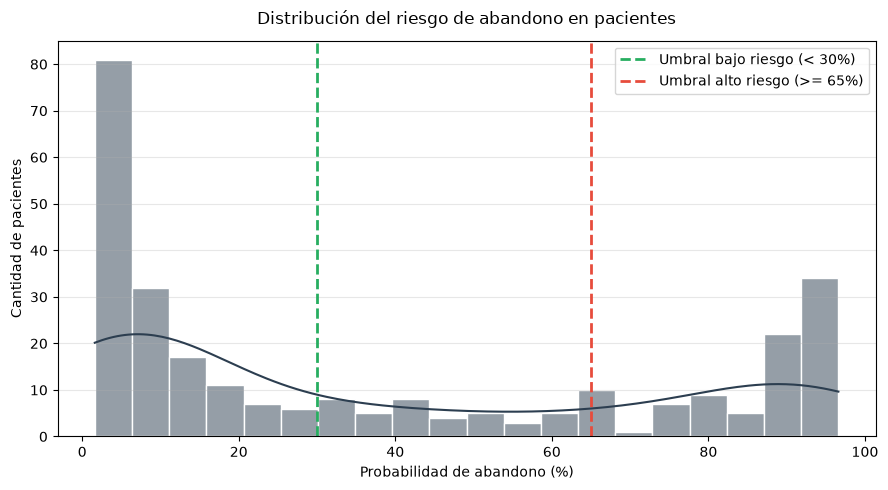

In [9]:
rf_produccion = RandomForestClassifier(
    n_estimators=150,
    max_depth=6,
    min_samples_split=8,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
)
modelo_calibrado = CalibratedClassifierCV(
    estimator=rf_produccion,
    method='sigmoid',
    cv=StratifiedKFold(n_splits=5, shuffle=False),
)
modelo_calibrado.fit(X_train[top7], y_train)

probs_fuga = modelo_calibrado.predict_proba(X_test[top7])[:, 1]
y_pred = (probs_fuga >= 0.5).astype(int)
auc = roc_auc_score(y_test, probs_fuga)
brier = brier_score_loss(y_test, probs_fuga)
loss = log_loss(y_test, probs_fuga)

print(f'AUC-ROC: {auc:.4f}')
print(f'Brier score: {brier:.4f}')
print(f'Log-loss: {loss:.4f}')
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred, target_names=['Fidelizado (0)', 'Fuga (1)']))

fpr, tpr, _ = roc_curve(y_test, probs_fuga)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#16a085', lw=3, label=f'Curva ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='#2c3e50', lw=1, linestyle='--')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Capacidad de discriminación del modelo (curva ROC)', fontsize=12, pad=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fraccion_positivos, prob_media = calibration_curve(y_test, probs_fuga, n_bins=10)
plt.figure(figsize=(8, 6))
plt.plot(prob_media, fraccion_positivos, 's-', color='#16a085', label='Modelo calibrado VetSur')
plt.plot([0, 1], [0, 1], '--', color='#7f8c8d', label='Calibración ideal')
plt.xlabel('Probabilidad predicha de fuga')
plt.ylabel('Fracción real de fuga')
plt.title('Curva de calibración probabilística', fontsize=12, pad=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.histplot(probs_fuga * 100, bins=20, kde=True, color='#2c3e50', edgecolor='white')
plt.axvline(30, color='#27ae60', linestyle='--', linewidth=2, label='Umbral bajo riesgo (< 30%)')
plt.axvline(65, color='#e74c3c', linestyle='--', linewidth=2, label='Umbral alto riesgo (>= 65%)')
plt.xlabel('Probabilidad de abandono (%)')
plt.ylabel('Cantidad de pacientes')
plt.title('Distribución del riesgo de abandono en pacientes', fontsize=12, pad=12)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
modelo_final = CalibratedClassifierCV(
    estimator=RandomForestClassifier(
        n_estimators=150,
        max_depth=6,
        min_samples_split=8,
        min_samples_leaf=4,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
    ),
    method='sigmoid',
    cv=StratifiedKFold(n_splits=5, shuffle=False),
)
modelo_final.fit(X[top7], y)
print('Modelo final reajustado sobre el 100% de los datos con las 7 features seleccionadas.')

Modelo final reajustado sobre el 100% de los datos con las 7 features seleccionadas.


In [11]:
import sklearn

assert list(modelo_final.feature_names_in_) == top7

ruta_csv_check = Path.cwd().parent / 'api' / 'caso1_vetsur.csv'
if not ruta_csv_check.exists():
    raise FileNotFoundError(f"Archivo de datos no encontrado: {ruta_csv_check.resolve()}")

joblib.dump(modelo_final, '../api/modelo_vetsur.pkl')

with open('../api/columnas_vetsur.json', 'w', encoding='utf-8') as f:
    json.dump(top7, f, indent=2)

imputaciones = {
    'mediana_monto': mediana_monto,
    'mediana_costo_global': mediana_costo_global,
    'mediana_costo_por_atencion': {k: float(v) for k, v in mediana_costo_por_atencion.items()},
}
with open('../api/imputaciones_vetsur.json', 'w', encoding='utf-8') as f:
    json.dump(imputaciones, f, indent=2)

ruta_pkl = (Path.cwd().parent / 'api' / 'modelo_vetsur.pkl').resolve()
print(f'Modelo exportado en {ruta_pkl} con {len(modelo_final.feature_names_in_)} features')
print(f'Columnas exportadas en {(Path.cwd().parent / "api" / "columnas_vetsur.json").resolve()}')
print(f'Imputaciones exportadas en {(Path.cwd().parent / "api" / "imputaciones_vetsur.json").resolve()}')
print(f'Versiones: numpy={np.__version__}, pandas={pd.__version__}, scikit-learn={sklearn.__version__}')

Modelo exportado en C:\Users\daemon\Documents\proyectosv2\vetsur\api\modelo_vetsur.pkl con 7 features
Columnas exportadas en C:\Users\daemon\Documents\proyectosv2\vetsur\api\columnas_vetsur.json
Imputaciones exportadas en C:\Users\daemon\Documents\proyectosv2\vetsur\api\imputaciones_vetsur.json
Versiones: numpy=2.4.6, pandas=3.0.5, scikit-learn=1.9.0


## Verificación y registro de versiones

Comandos de verificación desde `api/`:

```
python -m pytest tests/ -v
```

Registro de versiones clave del entorno de entrenamiento:

- Python 3.11.9
- NumPy 2.4.6
- Pandas 3.0.5
- Scikit-learn 1.9.0
- Ftfy 6.3.1
- Joblib 1.6.0

La reproducibilidad byte a byte queda condicionada a estas versiones fijas.